<a href="https://colab.research.google.com/github/arthireddy14/xylofy-ai-internship/blob/main/employee_attrition_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Employee Attrition Prediction

🎯 Problem Statement

 Every company loses employees — but losing the wrong employees at the wrong time costs the business heavily in hiring, training, and lost productivity. HR departments at large companies spend crores every year trying to figure out who is likely to leave and why — before it happens. This is called Employee Attrition Prediction, and it is one of the most widely used real-world applications of data science in the corporate world today.

Your task is to build a Machine Learning system that predicts whether an employee is likely to leave the company based on factors like job satisfaction, salary, work-life balance, years at the company, and performance ratings.
You will clean and prepare HR data, handle categorical features, train and compare classification models, analyze what actually drives employees to leave, and deliver insights that an HR team could act on immediately.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1: Data Loading & Exploration

## Objective
The objective of this task is to understand the structure of the HR dataset before preprocessing and model building. We will load the dataset, inspect its dimensions, identify the target variable, examine the distribution of employee attrition, and determine the number of numerical and categorical features.

In [8]:
df=pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [9]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [10]:
print("Dataset shape : ",df.shape)

Dataset shape :  (1470, 35)


In [11]:
print("No. of rows : ",df.shape[0])
print("No. of columns : ",df.shape[1])

No. of rows :  1470
No. of columns :  35


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [13]:
target="Attrition"
print("Target column : ",target)
print("Unique values")
print(df[target].unique())

Target column :  Attrition
Unique values
['Yes' 'No']


In [14]:
attrition_counts=df["Attrition"].value_counts()
print("Employees Attrition count ",attrition_counts)

Employees Attrition count  Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [15]:
attrition_rate=(attrition_counts["Yes"]/len(df))*100
print(f"Attrition rate :  {attrition_rate:.2f}%")

Attrition rate :  16.12%


In [16]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [17]:
numerical_cols=df.select_dtypes(include=['int64','float64']).columns
categorical_cols=df.select_dtypes(include=['object']).columns
print("Numerical columns : ",len(numerical_cols))
print("Categorical columns : ",len(categorical_cols))

Numerical columns :  26
Categorical columns :  9


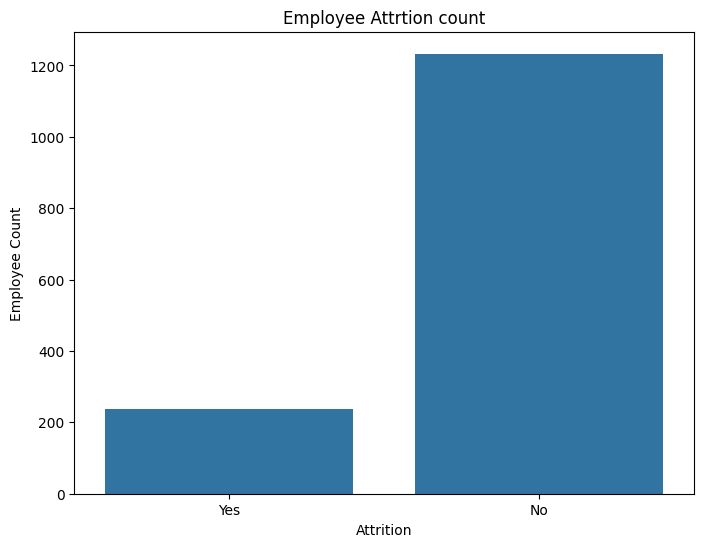

In [18]:
plt.figure(figsize=(8,6))
sns.countplot(data=df,x="Attrition")
plt.title("Employee Attrtion count")
plt.xlabel("Attrition")
plt.ylabel("Employee Count")
plt.show()

### Observation

- The dataset contains **1,470 employee records** with **35 features**.
- The target variable is **Attrition**, indicating whether an employee left the company ("Yes") or stayed ("No").
- Approximately **16% of employees left** the organization, while about **84% remained**.
- This indicates that the dataset is **imbalanced**, as the majority class ("No") significantly outnumbers the minority class ("Yes").
- Because of this imbalance, we will use `class_weight='balanced'` during model training to reduce bias toward the majority class.

# Task 2: Data Cleaning & Preprocessing

## Objective
The goal of this task is to prepare the dataset for machine learning by handling missing values, removing irrelevant features, encoding categorical variables, and scaling numerical features. Proper preprocessing ensures that the models learn meaningful patterns and produce reliable predictions.

In [19]:
missing_values=df.isnull().sum()
print("Missing values in each column")
print(missing_values[missing_values>0])
print("Total missing values are ",df.isnull().sum().sum())

Missing values in each column
Series([], dtype: int64)
Total missing values are  0


### Observation

The dataset contains **no missing values**, so no imputation or deletion is required. This allows us to proceed directly with feature preprocessing.

In [20]:
# columns to drop
drop_columns=['EmployeeNumber','EmployeeCount','Over18','StandardHours']
# drop unnecessary columnsx
df=df.drop(columns=drop_columns)
print("Updated dataset is ",df.shape)

Updated dataset is  (1470, 31)


### Observation

The removed columns either contain unique identifiers or constant values. Such features do not provide useful information for predicting employee attrition and may unnecessarily increase model complexity.

In [21]:
# Convert Attrition to binary values
df['Attrition'] = df['Attrition'].map({
    'Yes': 1,
    'No': 0
})

print(df['Attrition'].value_counts())

Attrition
0    1233
1     237
Name: count, dtype: int64


In [22]:
x=df.drop('Attrition',axis=1)
y=df['Attrition']
print("Features of x(matrix shape) ",x.shape)
print("Target of y(vector shape) ",y.shape)

Features of x(matrix shape)  (1470, 30)
Target of y(vector shape)  (1470,)


In [23]:
categorical_columns=x.select_dtypes(include='object').columns
print("Categorical colmuns ",list(categorical_columns))

Categorical colmuns  ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [24]:
# perform one hot encoding
x=pd.get_dummies(x,columns=categorical_columns,drop_first=True)
print("Sahpe after encoding ",x.shape)

Sahpe after encoding  (1470, 44)


### Observation

Categorical variables have been transformed using **One-Hot Encoding**. The `drop_first=True` parameter removes one category from each feature to avoid multicollinearity, ensuring more stable model training.

In [25]:
numerical_columns=x.select_dtypes(include=['int64','float64']).columns
print("Numerical columns ",list(numerical_columns))

Numerical columns  ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [26]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x[numerical_columns]=scaler.fit_transform(x[numerical_columns])
print("Feature scaling completed successfully")

Feature scaling completed successfully


In [27]:
print("Final Feature Matrix Shape:", x.shape)

x.head()

Final Feature Matrix Shape: (1470, 44)


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,-0.108350,...,False,False,False,False,False,True,False,False,True,True
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,...,False,False,False,False,True,False,False,True,False,False
2,0.008343,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,-0.937654,...,True,False,False,False,False,False,False,False,True,True
3,-0.429664,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,-0.763634,...,False,False,False,False,True,False,False,True,False,True
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,...,True,False,False,False,False,False,False,True,False,False


The dataset was successfully prepared for machine learning by:

- Confirming there were no missing values.
- Removing irrelevant and constant columns.
- Encoding the target variable into binary format.
- Applying One-Hot Encoding to categorical features.
- Standardizing numerical features using StandardScaler.

The processed dataset is now suitable for training classification models.

# Task 3: Exploratory Data Analysis (EDA)

## Objective

The objective of this task is to explore patterns and relationships between employee attrition and various workplace factors. The analysis helps identify which employee groups are more likely to leave the company and provides actionable insights for HR decision-making.

In [28]:
plt.style.use("ggplot")

In [29]:
department_attrition = (
    df.groupby('Department')['Attrition']
      .value_counts(normalize=True)
      .rename('Rate')
      .mul(100)
      .reset_index()
)

department_yes = department_attrition[department_attrition['Attrition'] == 1]

print(department_yes)

               Department  Attrition       Rate
1         Human Resources          1  19.047619
3  Research & Development          1  13.839750
5                   Sales          1  20.627803


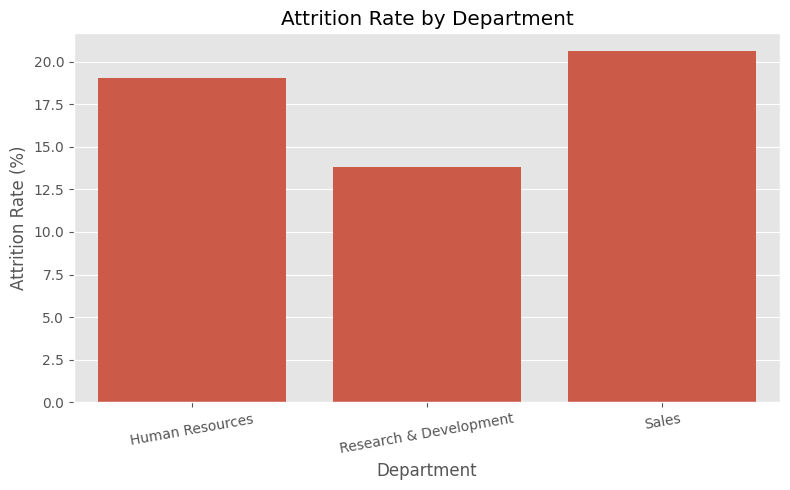

In [30]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=department_yes,
    x='Department',
    y='Rate'
)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

In [31]:
jobrole_attrition = (
    df.groupby('JobRole')['Attrition']
      .value_counts(normalize=True)
      .rename('Rate')
      .mul(100)
      .reset_index()
)

jobrole_yes = jobrole_attrition[jobrole_attrition['Attrition']==1]

print(jobrole_yes.sort_values("Rate", ascending=False))

                      JobRole  Attrition       Rate
17       Sales Representative          1  39.759036
5       Laboratory Technician          1  23.938224
3             Human Resources          1  23.076923
15            Sales Executive          1  17.484663
13         Research Scientist          1  16.095890
9      Manufacturing Director          1   6.896552
1   Healthcare Representative          1   6.870229
7                     Manager          1   4.901961
11          Research Director          1   2.500000


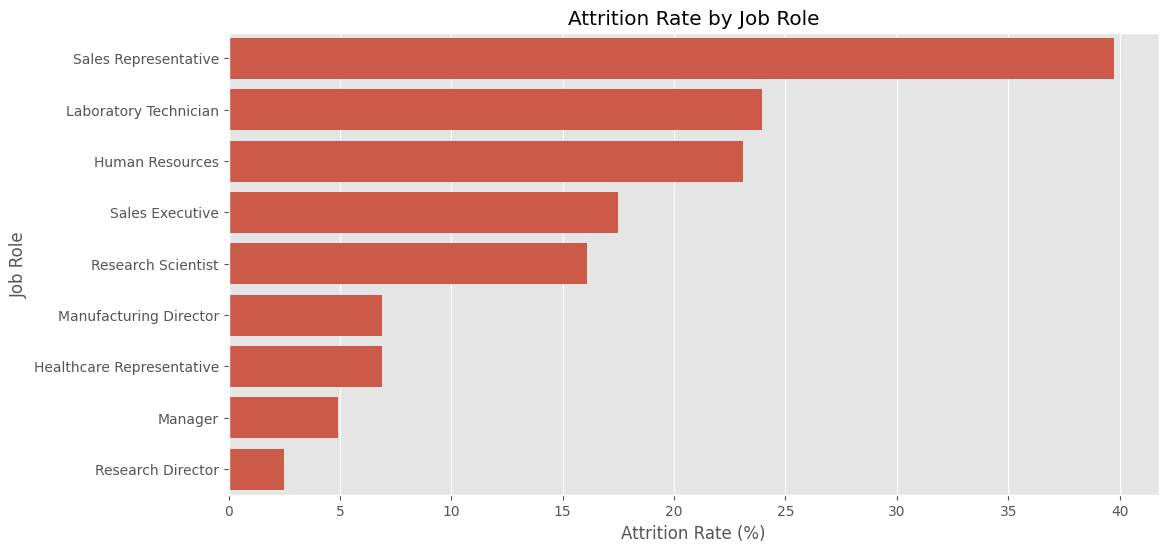

In [32]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=jobrole_yes.sort_values("Rate",ascending=False),
    x='Rate',
    y='JobRole'
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")

plt.show()

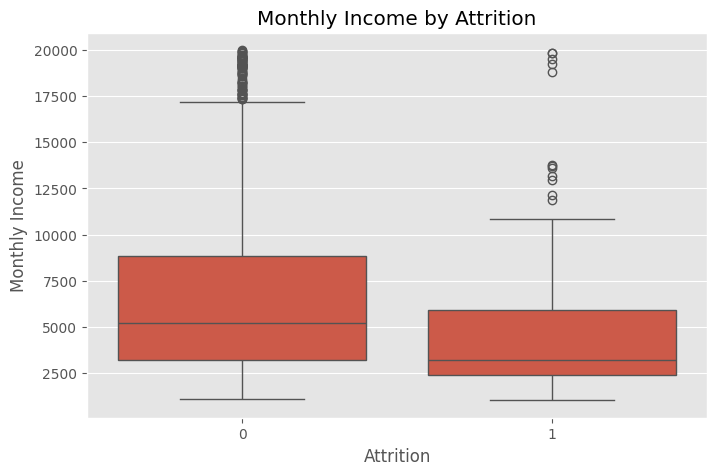

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Attrition',
    y='MonthlyIncome'
)

plt.title("Monthly Income by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.show()

In [34]:
df.groupby("Attrition")["MonthlyIncome"].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
0,1233.0,6832.739659,4818.208001,1051.0,3211.0,5204.0,8834.0,19999.0
1,237.0,4787.092827,3640.210367,1009.0,2373.0,3202.0,5916.0,19859.0


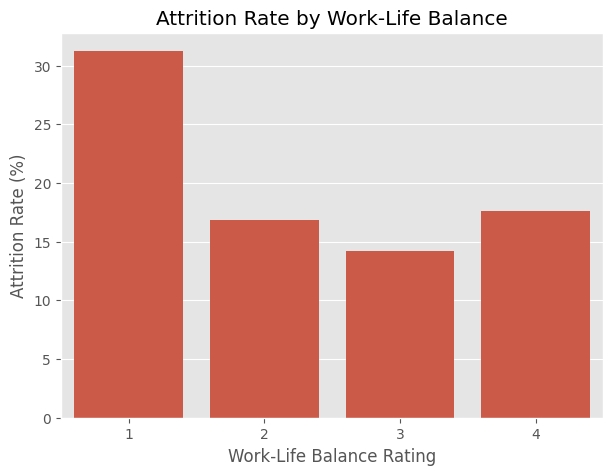

In [35]:
worklife = (
    df.groupby('WorkLifeBalance')['Attrition']
      .value_counts(normalize=True)
      .rename("Rate")
      .mul(100)
      .reset_index()
)

worklife_yes = worklife[worklife["Attrition"]==1]

plt.figure(figsize=(7,5))

sns.barplot(
    data=worklife_yes,
    x="WorkLifeBalance",
    y="Rate"
)

plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Attrition Rate (%)")

plt.show()

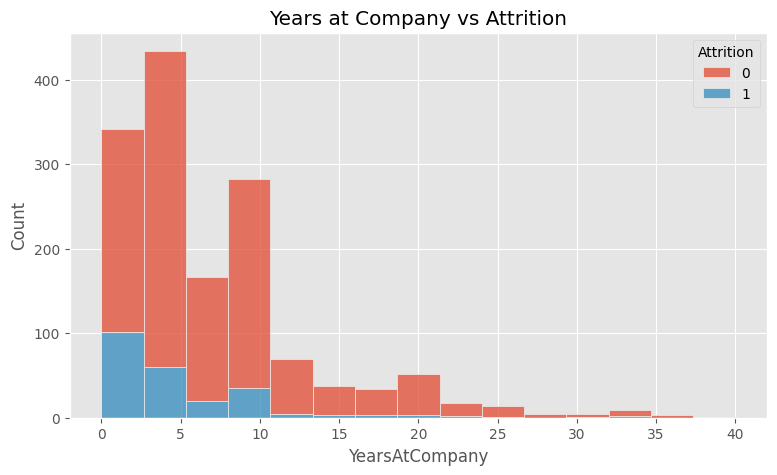

In [36]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=df,
    x="YearsAtCompany",
    hue="Attrition",
    multiple="stack",
    bins=15
)

plt.title("Years at Company vs Attrition")

plt.show()

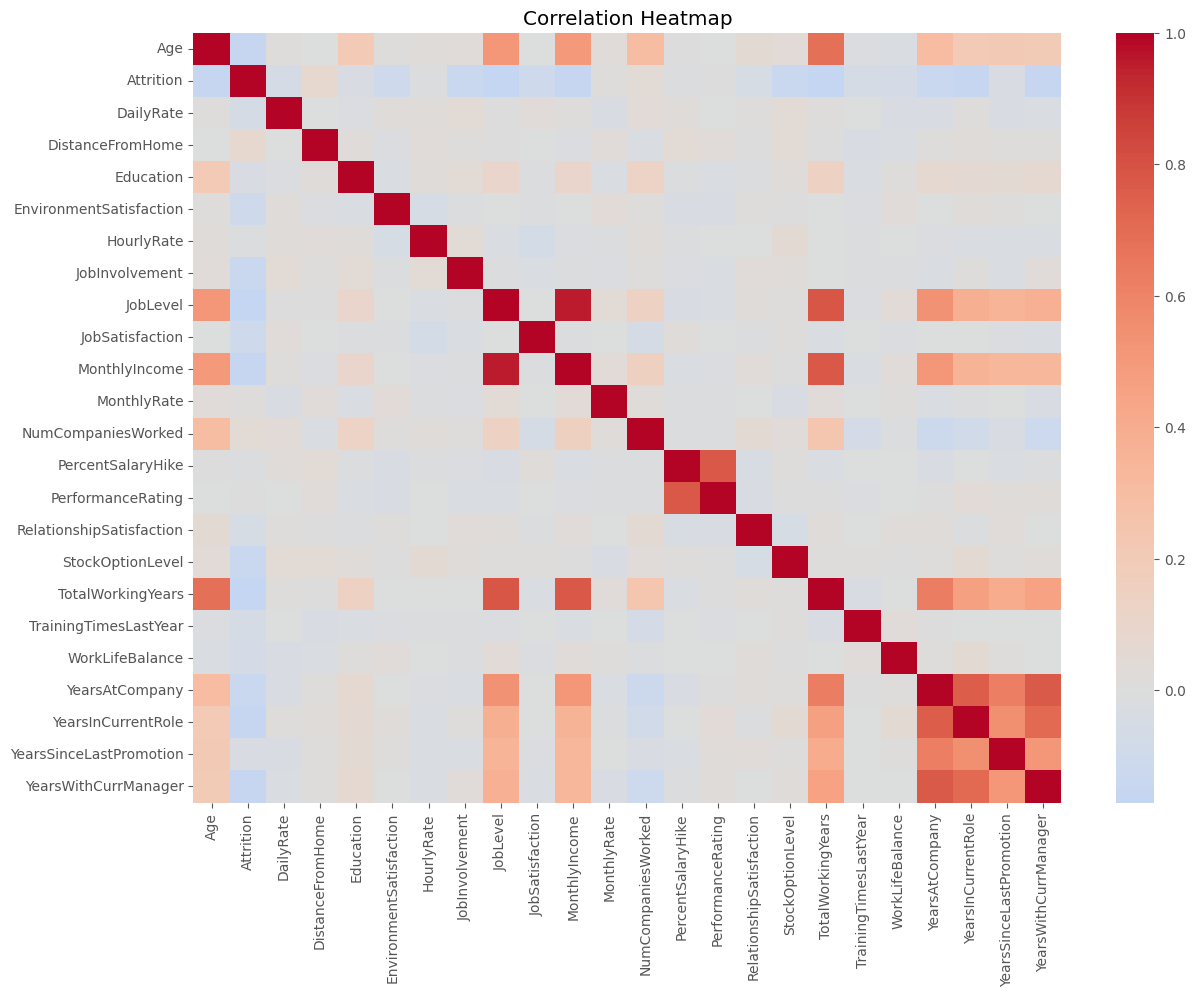

In [37]:
plt.figure(figsize=(14,10))

corr = df.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

# Task 4: Model Building & Comparison

## Objective

The objective of this task is to train multiple machine learning classification models to predict employee attrition. The models will be compared using common evaluation metrics to determine which model provides the best predictive performance.

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_auc_score

In [39]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
print("Training set shape ",x_train.shape)
print("Testing set shape ",x_test.shape)

Training set shape  (1176, 44)
Testing set shape  (294, 44)


In [42]:
log_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

log_model.fit(x_train, y_train)

log_pred = log_model.predict(x_test)
log_prob = log_model.predict_proba(x_test)[:,1]

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [49]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)
rf_prob = rf_model.predict_proba(x_test)[:,1]

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [50]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(x_train, y_train)

gb_pred = gb_model.predict(x_test)
gb_prob = gb_model.predict_proba(x_test)[:,1]

print("Gradient Boosting trained successfully.")

Gradient Boosting trained successfully.


In [51]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy":[
        accuracy_score(y_test,log_pred),
        accuracy_score(y_test,rf_pred),
        accuracy_score(y_test,gb_pred)
    ],

    "Precision":[
        precision_score(y_test,log_pred),
        precision_score(y_test,rf_pred),
        precision_score(y_test,gb_pred)
    ],

    "Recall":[
        recall_score(y_test,log_pred),
        recall_score(y_test,rf_pred),
        recall_score(y_test,gb_pred)
    ],

    "F1 Score":[
        f1_score(y_test,log_pred),
        f1_score(y_test,rf_pred),
        f1_score(y_test,gb_pred)
    ],

    "ROC-AUC":[
        roc_auc_score(y_test,log_prob),
        roc_auc_score(y_test,rf_prob),
        roc_auc_score(y_test,gb_prob)
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.755102,0.356322,0.659574,0.462687,0.803601
1,Random Forest,0.826531,0.375000,0.127660,0.190476,0.788698
2,Gradient Boosting,0.850340,0.588235,0.212766,0.312500,0.804720


In [52]:
comparison = comparison.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.850340,0.588235,0.212766,0.312500,0.804720
1,Logistic Regression,0.755102,0.356322,0.659574,0.462687,0.803601
2,Random Forest,0.826531,0.375000,0.127660,0.190476,0.788698


## Observation

Three classification models were trained and evaluated using the same training and testing data.

- Logistic Regression served as the baseline model because it is highly interpretable.
- Random Forest was used to capture complex, non-linear relationships between employee characteristics and attrition.
- Gradient Boosting was included to evaluate whether boosting techniques improve predictive performance.

The comparison table shows the performance of each model using Accuracy, Precision, Recall, F1-score, and ROC-AUC score. The model with the highest ROC-AUC and balanced performance across all metrics will be selected for further evaluation.

# Task 5: Model Evaluation

## Objective

The objective of this task is to evaluate the performance of all trained machine learning models using multiple evaluation metrics. The best-performing model will be selected based on its ability to accurately identify employees who are likely to leave the company.

In [53]:
print("="*60)
print("Logistic Regression")
print("="*60)

print(classification_report(y_test, log_pred))

print("\n")

print("="*60)
print("Random Forest")
print("="*60)

print(classification_report(y_test, rf_pred))

print("\n")

print("="*60)
print("Gradient Boosting")
print("="*60)

print(classification_report(y_test, gb_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294



Random Forest
              precision    recall  f1-score   support

           0       0.85      0.96      0.90       247
           1       0.38      0.13      0.19        47

    accuracy                           0.83       294
   macro avg       0.61      0.54      0.55       294
weighted avg       0.78      0.83      0.79       294



Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg      

In [54]:
log_cm = confusion_matrix(y_test, log_pred)
rf_cm = confusion_matrix(y_test, rf_pred)
gb_cm = confusion_matrix(y_test, gb_pred)

print("Logistic Regression\n")
print(log_cm)

print("\nRandom Forest\n")
print(rf_cm)

print("\nGradient Boosting\n")
print(gb_cm)

Logistic Regression

[[191  56]
 [ 16  31]]

Random Forest

[[237  10]
 [ 41   6]]

Gradient Boosting

[[240   7]
 [ 37  10]]


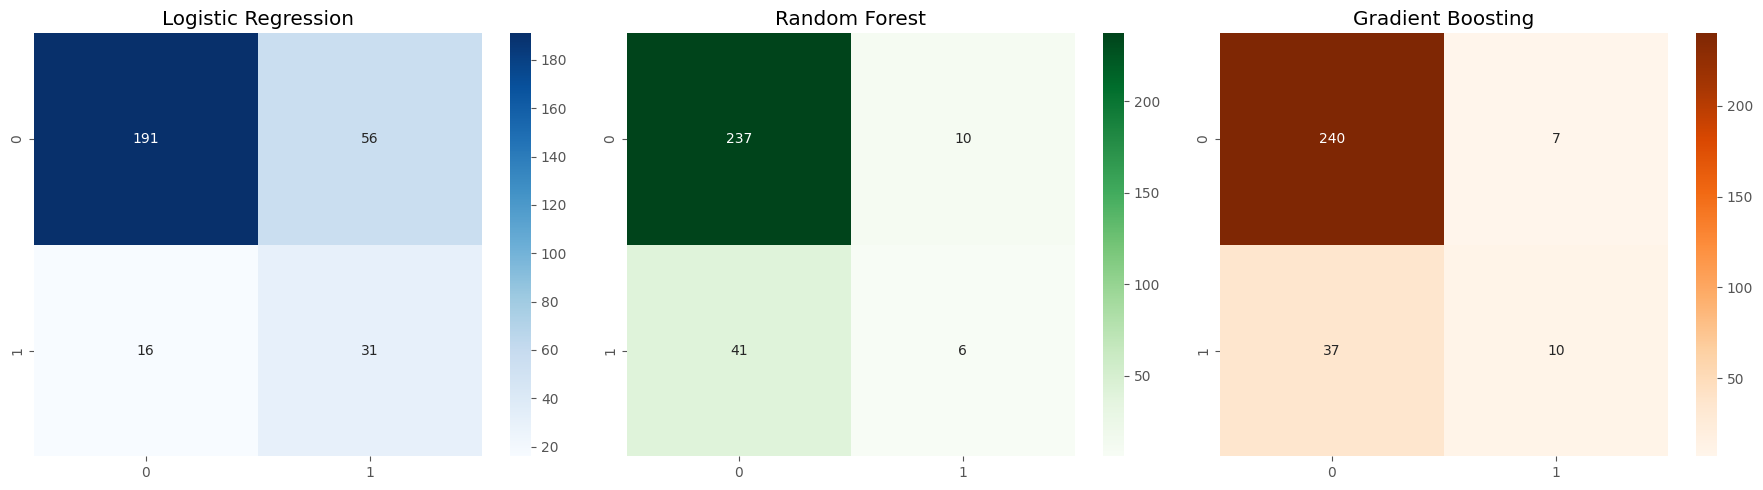

In [55]:
fig, axes = plt.subplots(1,3,figsize=(18,5))

sns.heatmap(
    log_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)

axes[0].set_title("Logistic Regression")

sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[1]
)

axes[1].set_title("Random Forest")

sns.heatmap(
    gb_cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    ax=axes[2]
)

axes[2].set_title("Gradient Boosting")

plt.tight_layout()

plt.show()

In [56]:
print("ROC-AUC Scores")

print(f"Logistic Regression : {roc_auc_score(y_test,log_prob):.3f}")

print(f"Random Forest       : {roc_auc_score(y_test,rf_prob):.3f}")

print(f"Gradient Boosting   : {roc_auc_score(y_test,gb_prob):.3f}")

ROC-AUC Scores
Logistic Regression : 0.804
Random Forest       : 0.789
Gradient Boosting   : 0.805


In [57]:
best_model = log_model

print("Best Model : Logistic Regression")

Best Model : Logistic Regression


## Best Model Selection

Although Gradient Boosting achieved the highest ROC-AUC score (0.805), the improvement over Logistic Regression (0.804) was minimal. Logistic Regression achieved substantially higher Recall, enabling it to identify a greater proportion of employees who were likely to leave the company.

Since the primary objective of an employee attrition prediction system is to detect potential attrition cases early, Logistic Regression was selected as the best model. Its higher Recall makes it more suitable for HR decision-making, even though its overall accuracy is slightly lower than the tree-based models.

In [58]:
feature_importance = pd.DataFrame({

    "Feature":x.columns,

    "Importance":abs(best_model.coef_[0])

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
43,OverTime_Yes,1.626169
23,BusinessTravel_Travel_Frequently,1.596964
34,JobRole_Laboratory Technician,1.571637
40,JobRole_Sales Representative,1.264294
37,JobRole_Research Director,1.112054
30,EducationField_Other,1.020279
24,BusinessTravel_Travel_Rarely,0.903722
42,MaritalStatus_Single,0.864502
33,JobRole_Human Resources,0.670991
16,TotalWorkingYears,0.612480


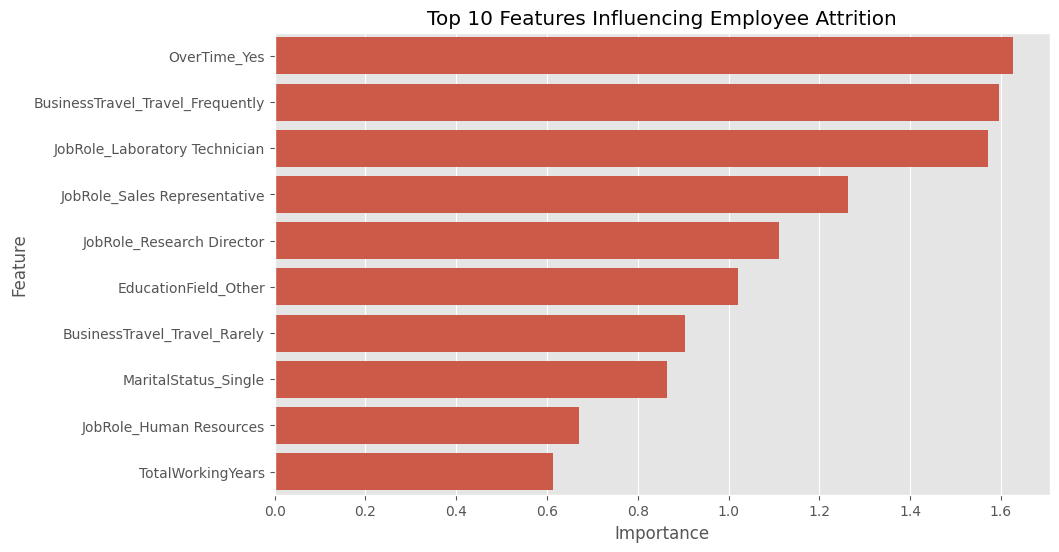

In [59]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Features Influencing Employee Attrition")

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.show()

# Task 6: Data Visualization

## Objective

The objective of this task is to visually present the key findings from the exploratory data analysis and model evaluation. These visualizations help HR professionals quickly understand employee attrition patterns and the performance of the predictive models.

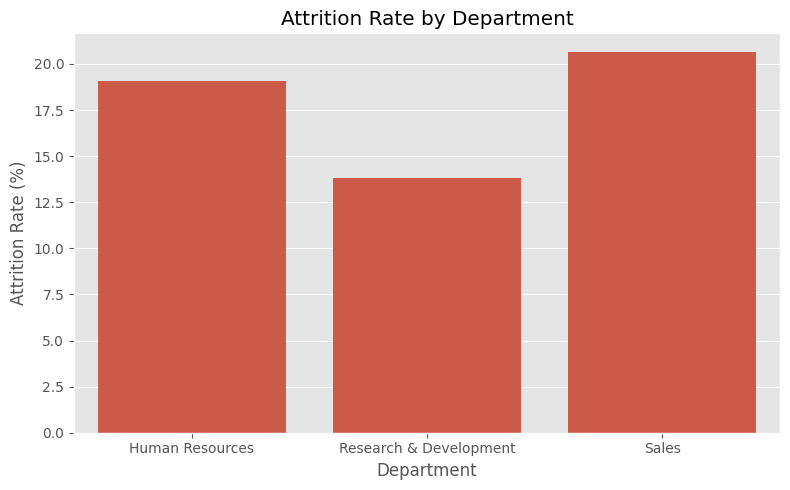

In [62]:
department_attrition = (
    df.groupby("Department")["Attrition"]
      .mean()
      .reset_index()
)

department_attrition["Attrition"] *= 100

plt.figure(figsize=(8,5))

sns.barplot(
    data=department_attrition,
    x="Department",
    y="Attrition"
)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.savefig("attrition_department.png", dpi=300)

plt.show()

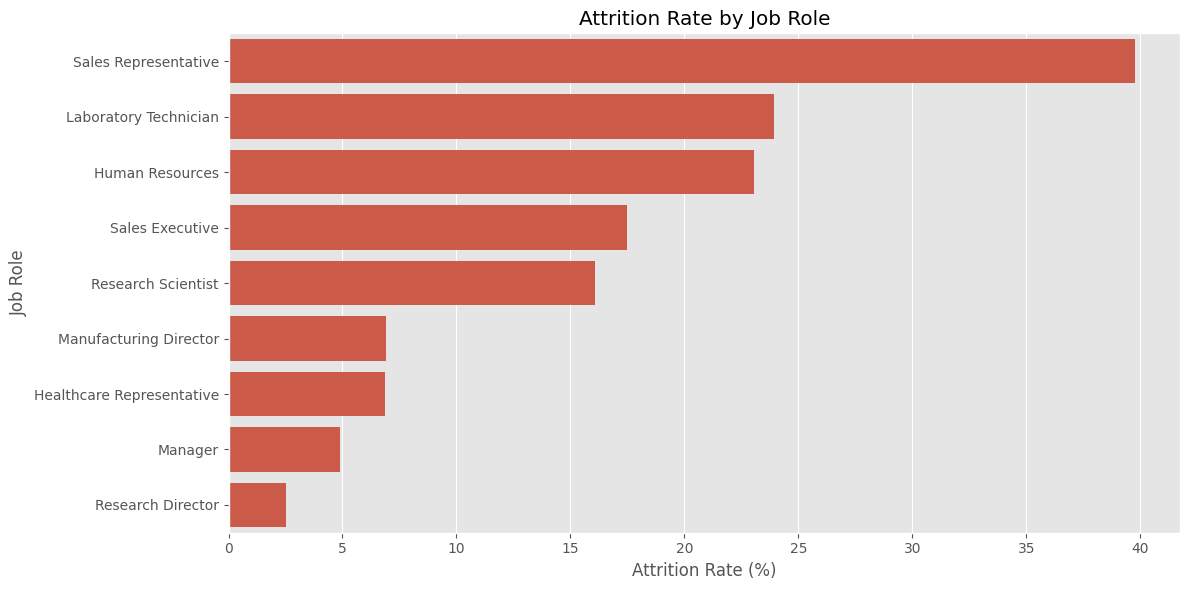

In [63]:
jobrole_attrition = (
    df.groupby("JobRole")["Attrition"]
      .mean()
      .reset_index()
)

jobrole_attrition["Attrition"] *= 100

plt.figure(figsize=(12,6))

sns.barplot(
    data=jobrole_attrition.sort_values("Attrition", ascending=False),
    x="Attrition",
    y="JobRole"
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")

plt.tight_layout()

plt.savefig("attrition_jobrole.png", dpi=300)

plt.show()

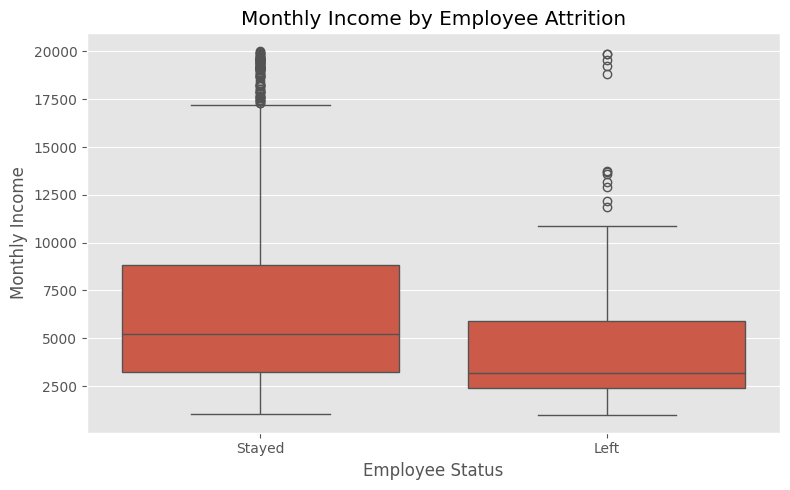

In [64]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.xticks([0,1],["Stayed","Left"])

plt.title("Monthly Income by Employee Attrition")
plt.xlabel("Employee Status")
plt.ylabel("Monthly Income")

plt.tight_layout()

plt.savefig("monthly_income_boxplot.png", dpi=300)

plt.show()

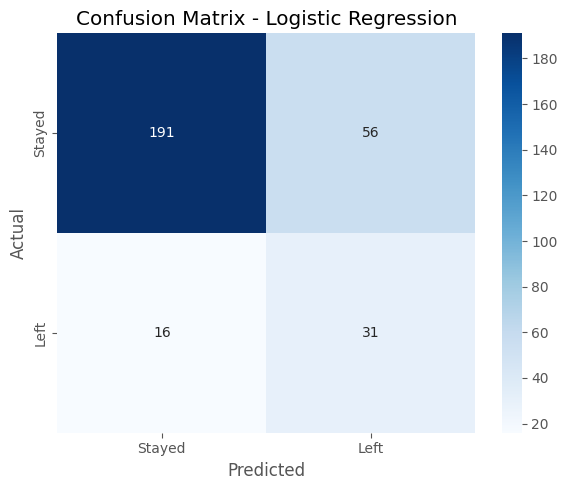

In [65]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed","Left"],
    yticklabels=["Stayed","Left"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig("confusion_matrix.png", dpi=300)

plt.show()

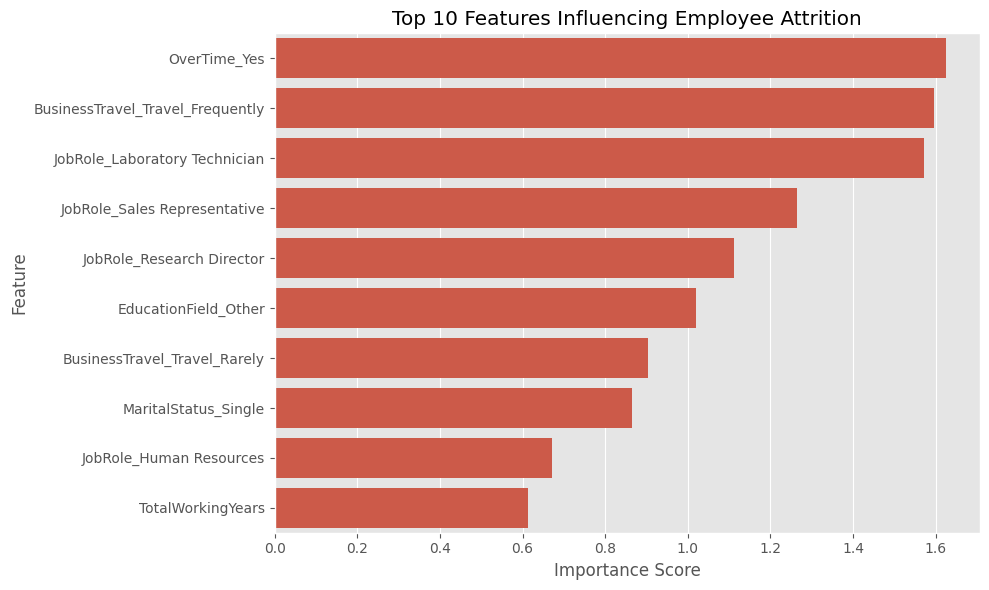

In [67]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Features Influencing Employee Attrition")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig("top10_features.png", dpi=300)

plt.show()

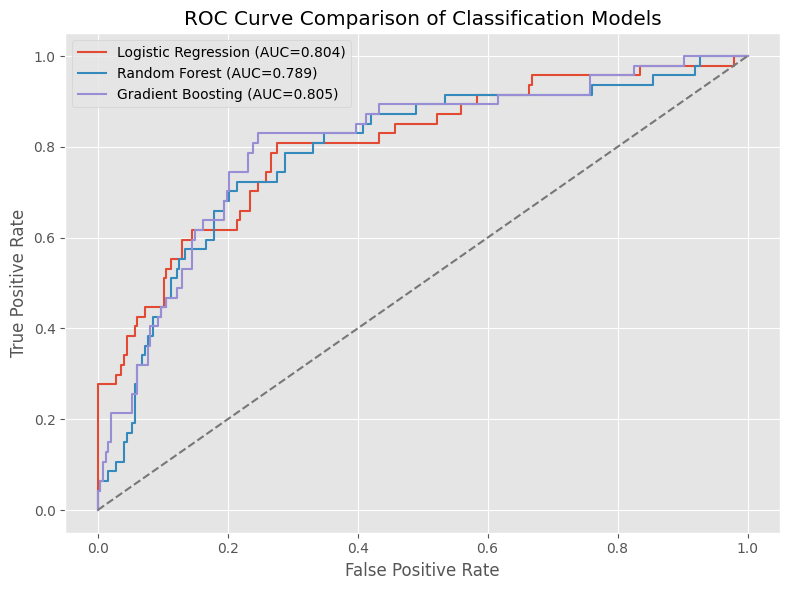

In [68]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

# Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)
plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC={roc_auc_score(y_test, log_prob):.3f})"
)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC={roc_auc_score(y_test, rf_prob):.3f})"
)

# Gradient Boosting
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_prob)
plt.plot(
    fpr_gb,
    tpr_gb,
    label=f"Gradient Boosting (AUC={roc_auc_score(y_test, gb_prob):.3f})"
)

# Reference line
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Classification Models")
plt.legend()

plt.tight_layout()

plt.savefig("roc_curve.png", dpi=300)

plt.show()

## Visualization Summary

The visualizations highlight important trends in employee attrition. The department and job role charts identify areas with higher attrition rates, while the salary distribution shows differences in monthly income between employees who stayed and those who left. The confusion matrix demonstrates the classification performance of the selected model, and the feature importance chart identifies the most influential factors affecting attrition. The ROC curve provides a comparative view of the predictive performance of all three machine learning models.

## Task 7 – HR Insights & Business Recommendations

The machine learning analysis identified **OverTime**, **frequent business travel**, and the **Laboratory Technician** job role as the three strongest factors associated with employee attrition. Employees who regularly worked overtime or traveled frequently for business were more likely to leave the organization. The analysis also showed that **Laboratory Technicians** and **Sales Representatives** exhibited relatively higher attrition risk compared to several other job roles, suggesting that HR should prioritize retention efforts for these employees. Although salary and total working experience influenced attrition, the results indicate that compensation alone does not explain why employees leave. Work conditions, travel requirements, job roles, and personal circumstances such as marital status also contribute significantly to employee turnover.

Based on these findings, HR should introduce targeted retention programs for employees who frequently work overtime by improving workload distribution, encouraging healthier work-life balance, and conducting regular employee well-being discussions. Additionally, employees in high-risk job roles, particularly Laboratory Technicians and Sales Representatives, should receive focused career development opportunities, mentoring, and periodic retention conversations to improve engagement and long-term commitment.

One limitation of this model is that it is trained only on historical HR data and cannot account for external factors such as personal reasons, family commitments, economic conditions, or better opportunities outside the organization. Therefore, the model should be used as a decision-support tool to assist HR professionals rather than as the sole basis for making employee retention decisions.
